# Logistic Regression on the Pima Indians Diabetes Database

**Goal:** predict the onset of diabetes from diagnostic measurements, and understand
*why* each modelling step is there.

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.model_selection import (train_test_split, GridSearchCV, StratifiedKFold,
                                     cross_val_score, cross_val_predict)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, recall_score,
                             confusion_matrix, classification_report,
                             roc_auc_score, roc_curve,
                             precision_recall_curve, average_precision_score)

sns.set_style('whitegrid')
%matplotlib inline

RANDOM_STATE = 42
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# scikit-learn 1.8 deprecated `penalty` in favour of `l1_ratio`.
# Both still work and give identical fits, but `penalty` emits noisy warnings,
# so we branch on the version to keep the output clean.
SK_MAJOR_MINOR = tuple(int(p) for p in sklearn.__version__.split('.')[:2])
SK_18_PLUS = SK_MAJOR_MINOR >= (1, 8)

print("scikit-learn:", sklearn.__version__, "| uses l1_ratio API:", SK_18_PLUS)

scikit-learn: 1.9.0 | uses l1_ratio API: True


## 1. Load the data and audit it before trusting it

**WHY.** Several copies of `diabetes.csv` circulate online. The original UCI file stores
*disguised missing values* as `0` in `Glucose`, `BloodPressure`, `SkinThickness`,
`Insulin` and `BMI` (a blood pressure of 0 is not a measurement).

Some popular re-uploads have already filled those zeros in — and a widely copied Kaggle
notebook does it by taking the **median within each `Outcome` class**. That is target
leakage: the feature value then encodes the label, and every downstream score is
optimistic. The audit below detects it.

In [ ]:
df = pd.read_csv('data/diabetes.csv')
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [4]:
ZERO_IMPOSSIBLE = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

zero_counts = (df[ZERO_IMPOSSIBLE] == 0).sum()
print("Zeros (disguised missing values) per column:")
print(zero_counts.to_string())
print(f"\nTotal: {zero_counts.sum()}")

if zero_counts.sum() == 0:
    print("\n>>> WARNING: no zeros found. This file has already been imputed by someone")
    print(">>> else, so the cleaning step below will do nothing. Run the leakage check.")
else:
    print("\nGood: this looks like the raw file. Expect roughly")
    print("Glucose 5 | BloodPressure 35 | SkinThickness 227 | Insulin 374 | BMI 11")

Zeros (disguised missing values) per column:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0

Total: 0

>>> WARNING: no zeros found. This file has already been imputed by someone
>>> else, so the cleaning step below will do nothing. Run the leakage check.


In [5]:
def leakage_audit(frame, cols, target='Outcome'):
    # Flag columns whose most repeated NON-ZERO value equals a class-conditional median.
    # Zeros are excluded because on the raw file they are the disguised missing values
    # themselves -- counting them would raise a false alarm on perfectly clean data.
    rows = []
    for col in cols:
        nz = frame[frame[col] != 0]
        vc = nz[col].value_counts()
        top_val, top_n = vc.index[0], int(vc.iloc[0])
        medians = nz.groupby(target)[col].median()
        hits = [k for k in medians.index if np.isclose(medians.loc[k], top_val)]
        share = top_n / len(frame)
        rows.append({
            'column': col,
            'n_zeros': int((frame[col] == 0).sum()),
            'most_common_nonzero': top_val,
            'n': top_n,
            'share_of_rows': round(share, 3),
            'equals_class_median_of': hits or None,
            'SUSPICIOUS': bool(hits) and share > 0.05,
        })
    return pd.DataFrame(rows)

audit = leakage_audit(df, ZERO_IMPOSSIBLE)
audit

,column,n_zeros,most_common_nonzero,n,share_of_rows,equals_class_median_of,SUSPICIOUS
0,Glucose,0,99.0,17,0.022,None,False
1,BloodPressure,0,70.0,76,0.099,[0],True
2,SkinThickness,0,27.0,162,0.211,[0],True
3,Insulin,0,102.5,236,0.307,[0],True
4,BMI,0,30.1,18,0.023,[0],False


**How to read the audit.**

`SUSPICIOUS = True` means one **non-zero** value is repeated in more than 5% of rows *and*
that value is exactly the median of one `Outcome` class. (Zeros are excluded from the
count: on the raw file they *are* the missing values, so including them would raise a false
alarm on perfectly clean data.) Legitimate biological data does not pile up
on a class median like that — an imputer does.

If any row is flagged (`Insulin` and `SkinThickness` are the usual culprits), **stop and
replace the file**. Download the original from
[UCI](https://archive.ics.uci.edu/dataset/34/diabetes) or the standard Kaggle
"Pima Indians Diabetes Database", where those columns are integers containing zeros.
Everything below will run either way, but the numbers only mean something on clean data.

## 2. Exploratory data analysis

Each display sits on its own final line — in the original notebook `df.describe()` was
followed by `print()` calls, and Jupyter only renders the **last** expression of a cell,
so that table was silently thrown away.

In [6]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Class distribution:
Outcome
0    500
1    268

Positive rate: 0.349


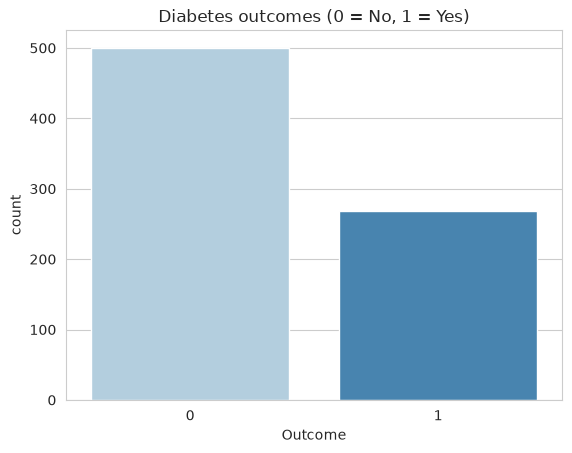

In [7]:
print("Class distribution:")
print(df['Outcome'].value_counts().to_string())
print("\nPositive rate:", round(df['Outcome'].mean(), 4))

sns.countplot(x='Outcome', data=df, hue='Outcome', palette='Blues', legend=False)
plt.title('Diabetes outcomes (0 = No, 1 = Yes)')
plt.show()

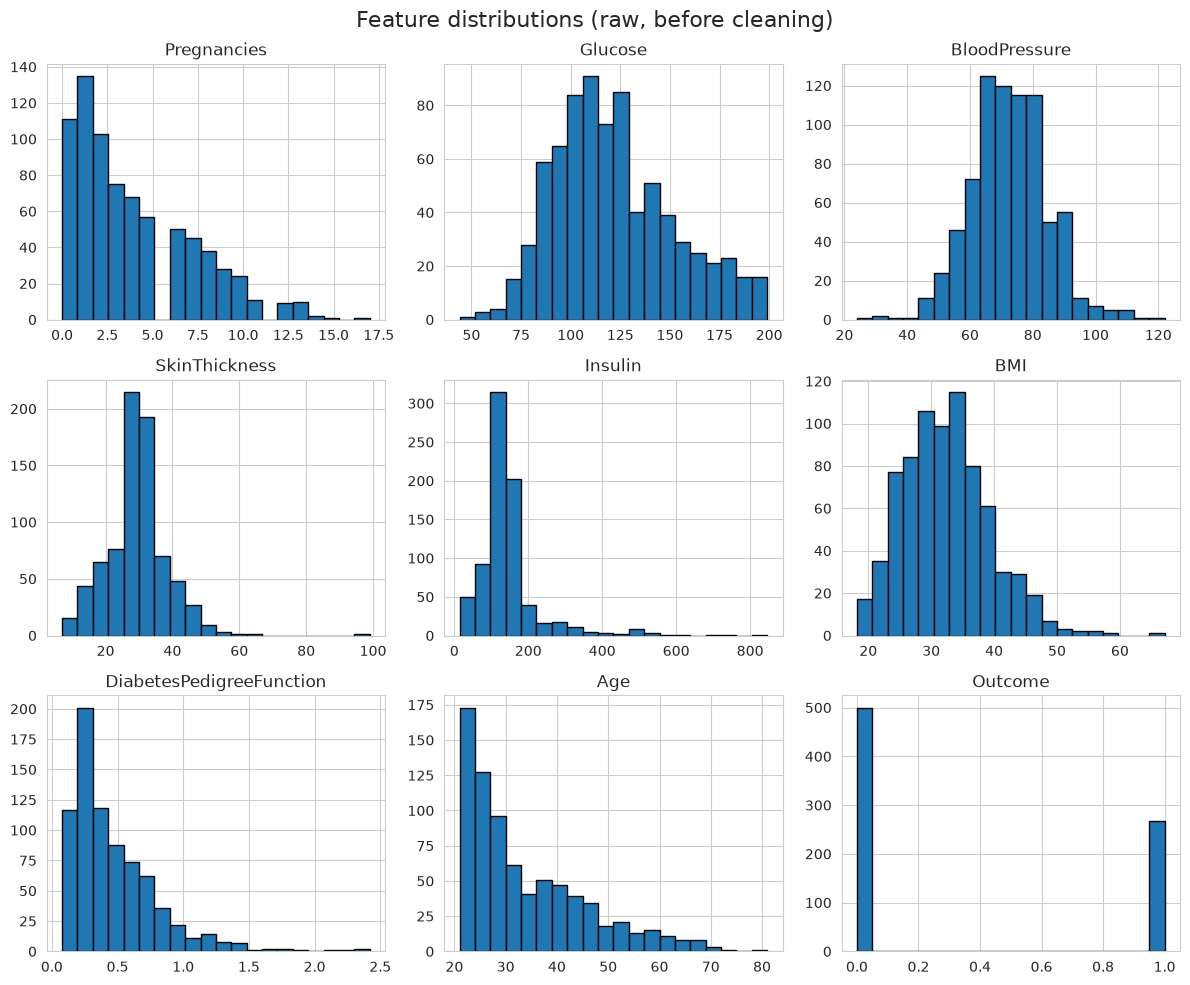

In [8]:
df.hist(figsize=(12, 10), bins=20, edgecolor='black')
plt.suptitle('Feature distributions (raw, before cleaning)', size=16)
plt.tight_layout()
plt.show()

Look at `Insulin` and `SkinThickness` above. On the **raw** file you should see a spike at
zero. A tall spike at some *interior* value instead (e.g. around 102 or 170) is the visual
signature of the class-conditional imputation the audit checks for.

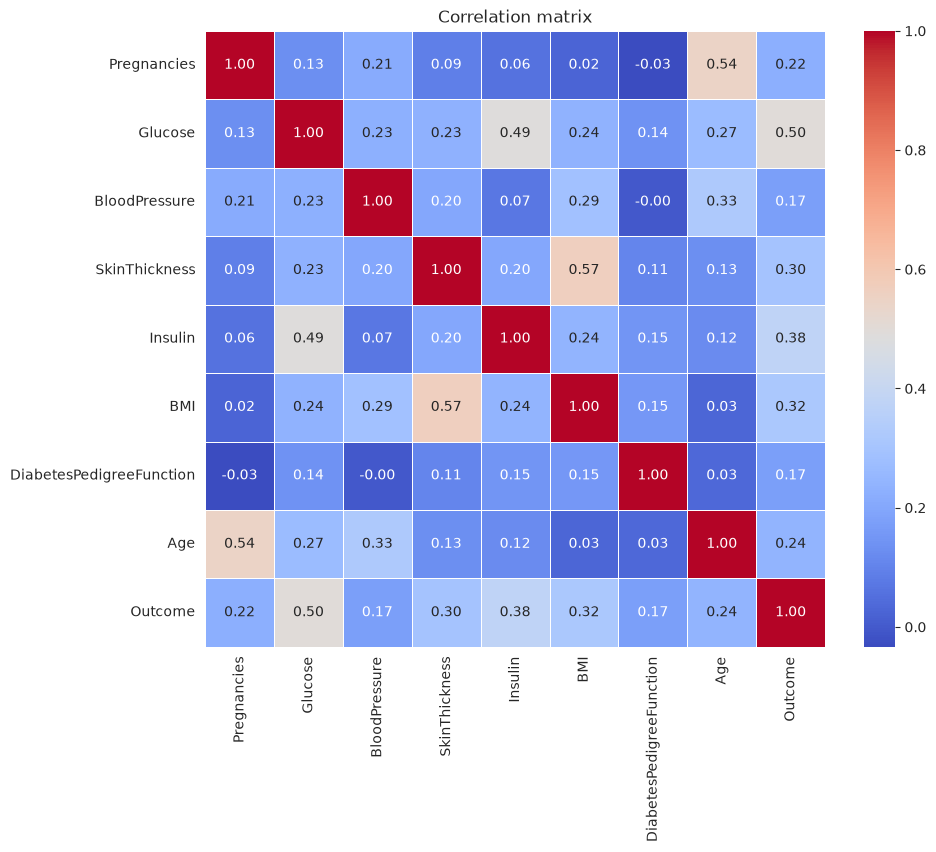

In [9]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation matrix')
plt.show()

## 3. Split first, clean later

**WHY.** This is the single most important structural change. In the original notebook
`df.fillna(df.median())` ran on all 768 rows *before* `train_test_split`, so the training
medians were computed partly from test rows. The test set has to stand in for data you
have never seen, so nothing derived from it may touch the fitting process.

So here we only convert the impossible zeros to `NaN` and split. **No imputation, no
scaling yet** — those become steps of the model in §4.

In [10]:
X = df.drop(columns='Outcome').copy()
X[ZERO_IMPOSSIBLE] = X[ZERO_IMPOSSIBLE].replace(0, np.nan)
y = df['Outcome'].copy()

print("Missing values now marked as NaN:")
print(X.isna().sum().to_string())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

print(f"\nTrain: {X_train.shape}  Test: {X_test.shape}")
print("Positive rate — train:", round(y_train.mean(), 4), "| test:", round(y_test.mean(), 4))

Missing values now marked as NaN:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0

Train: (614, 8)  Test: (154, 8)
Positive rate — train: 0.3485 | test: 0.3506


## 4. The model is a pipeline, not just the classifier

**WHY.** Imputation and scaling are *fitted* operations — they learn the medians and the
means/SDs. Wrapping them with the classifier means `cross_val_score` and `GridSearchCV`
refit all three on each training fold only, so the validation fold stays untouched.

On scaling: unpenalised logistic regression does **not** need it — rescaling a predictor
just divides its coefficient by the same factor and leaves the fitted probabilities
identical. It matters here for two other reasons: the L1/L2 penalty is scale-dependent
(unscaled, a feature measured in small units gets punished harder), and equal scales make
coefficient magnitudes comparable in §7.

In [11]:
def build_pipeline(**clf_kwargs):
    params = dict(solver='liblinear', max_iter=1000, random_state=RANDOM_STATE)
    params.update(clf_kwargs)
    return Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale',  StandardScaler()),
        ('clf',    LogisticRegression(**params)),
    ])

baseline = build_pipeline()
cv_auc = cross_val_score(baseline, X_train, y_train, cv=CV, scoring='roc_auc')
print(f"Baseline pipeline — CV ROC-AUC: {cv_auc.mean():.4f} (+/- {cv_auc.std():.4f})")
print("Per fold:", np.round(cv_auc, 4))

Baseline pipeline — CV ROC-AUC: 0.8716 (+/- 0.0167)
Per fold: [0.8767 0.8715 0.8919 0.8767 0.8411]


## 5. Fit and evaluate — with a reference point

**WHY.** An accuracy of 0.71 sounds fine until you notice that always predicting "no
diabetes" scores about 0.65 on this data. Always print the majority-class rate next to
your accuracy, and put an interval on the AUC: on ~154 test rows the sampling noise is
around ±0.06, so small differences between models are not real.

In [12]:
model = build_pipeline().fit(X_train, y_train)

y_proba = model.predict_proba(X_test)[:, 1]
y_pred  = (y_proba >= 0.5).astype(int)

majority = float(y_test.value_counts(normalize=True).max())

print("===== Baseline model (threshold 0.50) =====")
print(f"Majority-class accuracy : {majority:.4f}   <- beat this")
print(f"Accuracy                : {accuracy_score(y_test, y_pred):.4f}")
print(f"Balanced accuracy       : {balanced_accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC                 : {roc_auc_score(y_test, y_proba):.4f}")
print(f"Average precision (PR)  : {average_precision_score(y_test, y_proba):.4f}")
print("\n" + classification_report(y_test, y_pred, target_names=['No diabetes', 'Diabetes']))

===== Baseline model (threshold 0.50) =====
Majority-class accuracy : 0.6494   <- beat this
Accuracy                : 0.7078
Balanced accuracy       : 0.6728
ROC-AUC                 : 0.8263
Average precision (PR)  : 0.6494

              precision    recall  f1-score   support

 No diabetes       0.77      0.79      0.78       100
    Diabetes       0.59      0.56      0.57        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.70      0.71      0.71       154



In [13]:
def auc_bootstrap_ci(y_true, y_score, n_boot=2000, seed=RANDOM_STATE):
    # Percentile bootstrap CI for ROC-AUC.
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    n = len(y_true)
    stats = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, n)
        if len(np.unique(y_true[idx])) < 2:
            continue
        stats.append(roc_auc_score(y_true[idx], y_score[idx]))
    return np.percentile(stats, [2.5, 97.5])

lo, hi = auc_bootstrap_ci(y_test, y_proba)
print(f"Test ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}  95% CI [{lo:.4f}, {hi:.4f}]")
print(f"CI width: {hi - lo:.4f}  -> differences smaller than this are noise.")

Test ROC-AUC: 0.8263  95% CI [0.7563, 0.8859]
CI width: 0.1295  -> differences smaller than this are noise.


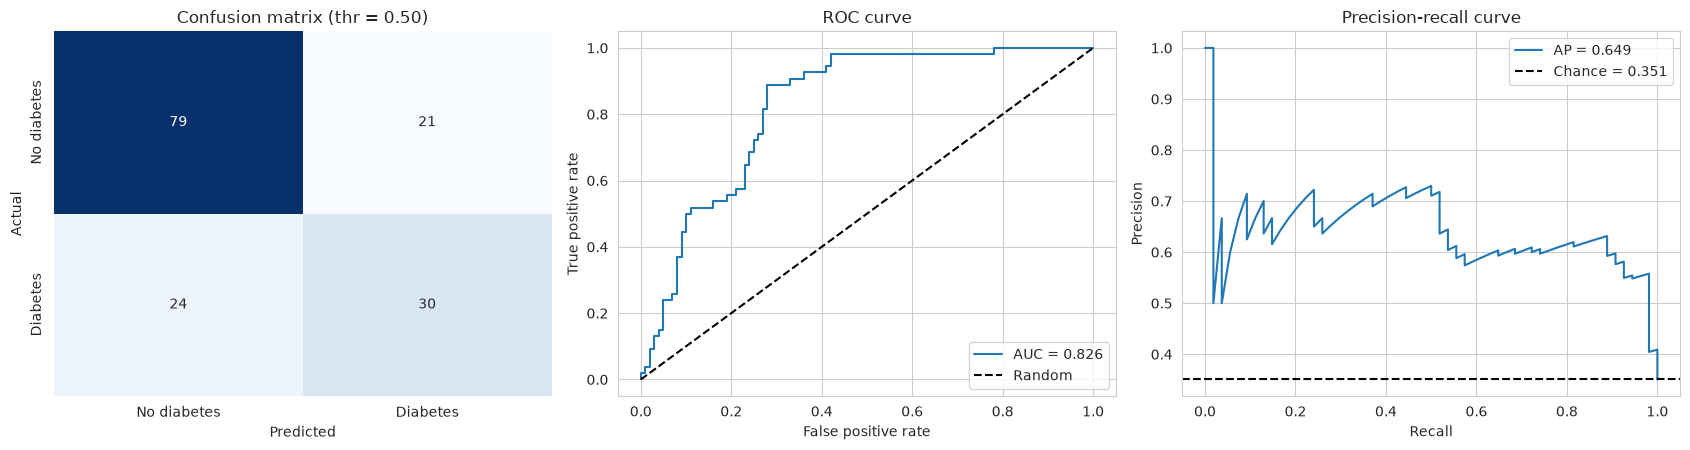

Missed diabetics (false negatives): 24 out of 54 actual cases


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['No diabetes', 'Diabetes'],
            yticklabels=['No diabetes', 'Diabetes'])
axes[0].set(xlabel='Predicted', ylabel='Actual', title='Confusion matrix (thr = 0.50)')

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_proba):.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random')
axes[1].set(xlabel='False positive rate', ylabel='True positive rate', title='ROC curve')
axes[1].legend(loc='lower right')

prec, rec, _ = precision_recall_curve(y_test, y_proba)
axes[2].plot(rec, prec, label=f'AP = {average_precision_score(y_test, y_proba):.3f}')
axes[2].axhline(y_test.mean(), ls='--', c='k', label=f'Chance = {y_test.mean():.3f}')
axes[2].set(xlabel='Recall', ylabel='Precision', title='Precision-recall curve')
axes[2].legend(loc='upper right')

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"Missed diabetics (false negatives): {fn} out of {fn + tp} actual cases")

**WHY the PR curve.** ROC can look flattering when the positive class is the minority.
The precision-recall curve conditions on the positives, so it shows what a screening
programme would actually experience.

## 6. Statistical inference — ISLP Table 4.1

**WHY.** scikit-learn is a prediction library: it gives coefficients and nothing else.
Your notes are built around *standard error, z-statistic and p-value*, where
z = beta-hat / SE(beta-hat) tests H0: beta_j = 0. For that you need `statsmodels`.

Two differences from the pipeline above: `statsmodels` fits **unpenalised maximum
likelihood** (the estimator in ISLP §4.3.2), whereas scikit-learn applies an L2 penalty by
default; and it needs the design matrix pre-built, so we apply the *already-fitted*
imputer and scaler rather than fitting new ones.

In [15]:
try:
    import statsmodels.api as sm
except ImportError:
    sm = None
    print("statsmodels not installed. Run:  pip install statsmodels")

if sm is not None:
    X_train_design = pd.DataFrame(
        model.named_steps['scale'].transform(
            model.named_steps['impute'].transform(X_train)),
        columns=X_train.columns, index=X_train.index)

    logit_res = sm.Logit(y_train, sm.add_constant(X_train_design)).fit(disp=0)
    print(logit_res.summary())

                           Logit Regression Results                           
Dep. Variable:                Outcome   No. Observations:                  614
Model:                          Logit   Df Residuals:                      605
Method:                           MLE   Df Model:                            8
Date:                Thu, 20 Aug 2026   Pseudo R-squ.:                  0.3303
Time:                        23:05:59   Log-Likelihood:                -265.85
converged:                       True   LL-Null:                       -396.97
Covariance Type:            nonrobust   LLR p-value:                 4.361e-52
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       -0.8951      0.114     -7.823      0.000      -1.119      -0.671
Pregnancies                  0.3433      0.123      2.802      0.005       0.103       0.

In [16]:
if sm is not None:
    inference = pd.DataFrame({
        'Coefficient': logit_res.params,
        'Std. error': logit_res.bse,
        'z-statistic': logit_res.tvalues,
        'p-value': logit_res.pvalues,
        'Odds ratio': np.exp(logit_res.params),
    }).round(4)
    display(inference)

    sig = inference[(inference['p-value'] < 0.05) & (inference.index != 'const')]
    print("Significant at the 5% level:", list(sig.index))

,Coefficient,Std. error,z-statistic,p-value,Odds ratio
const,-0.8951,0.1144,-7.8230,0.0000,0.4086
Pregnancies,0.3433,0.1225,2.8022,0.0051,1.4096
Glucose,0.9487,0.1360,6.9763,0.0000,2.5823
BloodPressure,-0.0087,0.1213,-0.0719,0.9427,0.9913
SkinThickness,0.2962,0.1407,2.1054,0.0353,1.3447
Insulin,0.6221,0.1627,3.8229,0.0001,1.8629
BMI,0.4729,0.1411,3.3513,0.0008,1.6047
DiabetesPedigreeFunction,0.1757,0.1134,1.5494,0.1213,1.1920
Age,0.1592,0.1246,1.2782,0.2012,1.1726


Significant at the 5% level: ['Pregnancies', 'Glucose', 'SkinThickness', 'Insulin', 'BMI']


**Reading it.** A large |z| is evidence against beta_j = 0. The intercept is rarely of
interest — as your notes put it, its job is to line the average fitted probability up with
the overall positive rate.

Beware of interpreting a single predictor in isolation: ISLP's `student` example shows a
coefficient flipping sign between the simple and the multiple model because `student` and
`balance` are correlated. **Confounding.** The same risk lives in the `Age` /
`Pregnancies` / `SkinThickness` / `BMI` correlations you plotted in §2.

## 7. Interpreting the coefficients

**WHY.** In `log(p/(1-p)) = b0 + b1*X1 + ... + bp*Xp`, a one-unit rise in Xj adds bj to the
**log odds** and multiplies the **odds** by exp(bj). It does *not* change p by a fixed
amount — the effect on probability depends on where you already are on the S-curve.

Because we fitted on standardised features, "one unit" here means **one standard
deviation**. Dividing by the scaler's `scale_` converts back to raw units (per mg/dL, per
kg/m²), which is what you would report clinically.

In [17]:
clf = model.named_steps['clf']
sds = model.named_steps['scale'].scale_

coef_scaled = clf.coef_[0]
coef_raw = coef_scaled / sds

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'SD of feature': sds,
    'Coef (per 1 SD)': coef_scaled,
    'Odds ratio (per 1 SD)': np.exp(coef_scaled),
    'Coef (per raw unit)': coef_raw,
    'Odds ratio (per raw unit)': np.exp(coef_raw),
}).sort_values('Coef (per 1 SD)', key=lambda s: s.abs(), ascending=False).reset_index(drop=True)

coef_df.round(4)

,Feature,SD of feature,Coef (per 1 SD),Odds ratio (per 1 SD),Coef (per raw unit),Odds ratio (per raw unit)
0,Glucose,30.0069,0.9327,2.5413,0.0311,1.0316
1,Insulin,81.6282,0.6141,1.8480,0.0075,1.0076
2,BMI,6.8240,0.4643,1.5909,0.0680,1.0704
3,Pregnancies,3.3114,0.3364,1.3999,0.1016,1.1069
4,SkinThickness,8.9791,0.2933,1.3409,0.0327,1.0332
5,DiabetesPedigreeFunction,0.3300,0.1747,1.1909,0.5293,1.6977
6,Age,11.8238,0.1583,1.1716,0.0134,1.0135
7,BloodPressure,12.2728,-0.0043,0.9958,-0.0003,0.9997


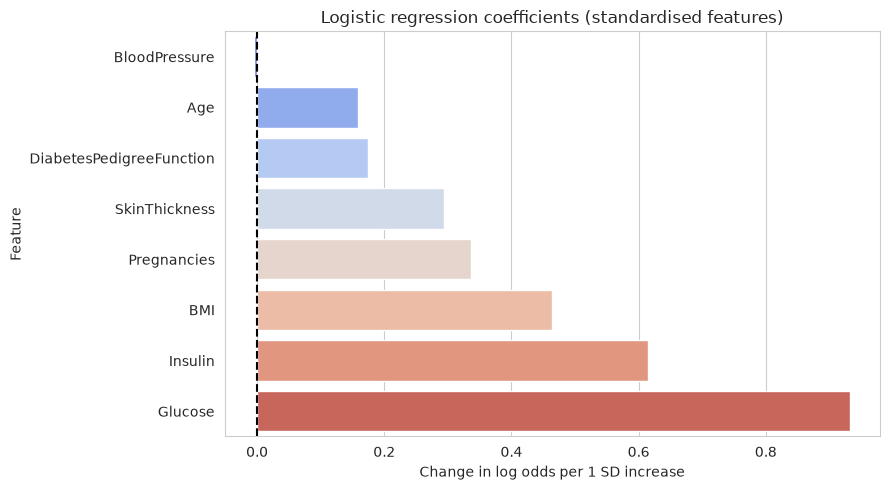

Example: a 1 SD increase in Glucose (30.01 units) multiplies the odds of diabetes by 2.54.


In [18]:
plot_df = coef_df.sort_values('Coef (per 1 SD)')
plt.figure(figsize=(9, 5))
sns.barplot(data=plot_df, x='Coef (per 1 SD)', y='Feature',
            hue='Feature', palette='coolwarm', legend=False)
plt.axvline(0, color='black', linestyle='--')
plt.title('Logistic regression coefficients (standardised features)')
plt.xlabel('Change in log odds per 1 SD increase')
plt.tight_layout()
plt.show()

top = coef_df.iloc[0]
print(f"Example: a 1 SD increase in {top['Feature']} ({top['SD of feature']:.2f} units) "
      f"multiplies the odds of diabetes by {top['Odds ratio (per 1 SD)']:.2f}.")

Note the ordering is by **absolute** value — for importance, a coefficient of -0.6 outranks
one of +0.3. Sorting by the signed value (as the original did) buries the protective
predictors at the bottom.

## 8. Tuning the regularisation

**WHY.** `C` is the *inverse* penalty strength: small `C` = heavy shrinkage. L1 can drive
coefficients exactly to zero (feature selection); L2 shrinks them together. Cross-validation
picks the value — as a rule, whenever an exam asks how to choose a tuning parameter, the
answer is cross-validation.

The grid is version-aware. In scikit-learn 1.8 `penalty` is deprecated in favour of
`l1_ratio` (0 = ridge, 1 = lasso). Both still fit **identically** — the deprecation warning
is noise, not a bug — but the new argument keeps the output readable.

In [19]:
C_grid = np.logspace(-3, 2, 12)
param_grid = ({'clf__C': C_grid, 'clf__l1_ratio': [0.0, 1.0]} if SK_18_PLUS
              else {'clf__C': C_grid, 'clf__penalty': ['l1', 'l2']})

grid = GridSearchCV(build_pipeline(), param_grid, cv=CV,
                    scoring='roc_auc', n_jobs=-1, refit=True)
try:
    grid.fit(X_train, y_train)
except (ValueError, TypeError) as err:
    print("Penalty axis unsupported here; tuning C only.\n ", err)
    grid = GridSearchCV(build_pipeline(), {'clf__C': C_grid}, cv=CV,
                        scoring='roc_auc', n_jobs=-1).fit(X_train, y_train)

print("Best parameters :", grid.best_params_)
print(f"Best CV ROC-AUC : {grid.best_score_:.4f}")

Best parameters : {'clf__C': np.float64(0.0657933224657568), 'clf__l1_ratio': 0.0}
Best CV ROC-AUC : 0.8738


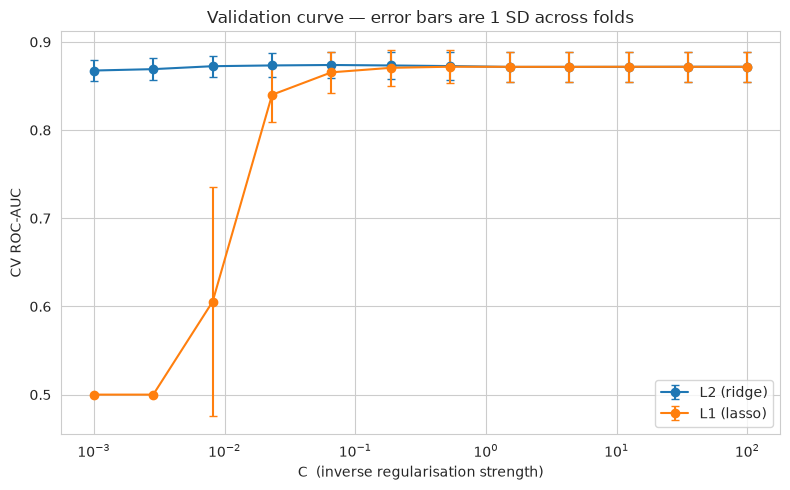

In [20]:
res = pd.DataFrame(grid.cv_results_)
pen_col = 'param_clf__l1_ratio' if SK_18_PLUS else 'param_clf__penalty'

plt.figure(figsize=(8, 5))
for key, sub in res.groupby(pen_col, dropna=False):
    sub = sub.sort_values('param_clf__C')
    label = ({0.0: 'L2 (ridge)', 1.0: 'L1 (lasso)'}.get(key, key)
             if SK_18_PLUS else {'l1': 'L1 (lasso)', 'l2': 'L2 (ridge)'}.get(key, key))
    plt.errorbar(sub['param_clf__C'].astype(float), sub['mean_test_score'],
                 yerr=sub['std_test_score'], marker='o', capsize=3, label=label)

plt.xscale('log')
plt.xlabel('C  (inverse regularisation strength)')
plt.ylabel('CV ROC-AUC')
plt.title('Validation curve — error bars are 1 SD across folds')
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
best_model = grid.best_estimator_
y_proba_t = best_model.predict_proba(X_test)[:, 1]
y_pred_t  = (y_proba_t >= 0.5).astype(int)

auc_base, auc_tuned = roc_auc_score(y_test, y_proba), roc_auc_score(y_test, y_proba_t)

print("===== Baseline vs tuned (test set) =====")
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}  ->  {accuracy_score(y_test, y_pred_t):.4f}")
print(f"ROC-AUC  : {auc_base:.4f}  ->  {auc_tuned:.4f}   (difference {auc_tuned - auc_base:+.4f})")
print(f"\nBootstrap CI width was {hi - lo:.4f}.")
print("If the difference above is much smaller than that, the two models are tied —")
print("report them as equivalent rather than declaring a winner.")
print(f"\nNote: best CV score ({grid.best_score_:.4f}) exceeding the test score is normal.")
print("The CV score was used to *choose* the model, so it is optimistic by construction.")

===== Baseline vs tuned (test set) =====
Accuracy : 0.7078  ->  0.7143
ROC-AUC  : 0.8263  ->  0.8272   (difference +0.0009)

Bootstrap CI width was 0.1295.
If the difference above is much smaller than that, the two models are tied —
report them as equivalent rather than declaring a winner.

Note: best CV score (0.8738) exceeding the test score is normal.
The CV score was used to *choose* the model, so it is optimistic by construction.


## 9. Choosing the threshold

**WHY.** `.predict()` hardwires 0.5, but 0.5 is a *decision*, not a property of the model.
Your notes make exactly this point: a lender worried about defaults might use 0.1 instead.
Here a false negative is a missed diabetic and a false positive is one extra blood test —
so 0.5 is almost certainly too strict.

Critically, the threshold is a tuning parameter, so it is chosen with **cross-validation on
the training set**, never on the test set. `cross_val_predict` gives out-of-fold
probabilities for exactly this.

Threshold maximising F1 (out-of-fold)      : 0.362
Threshold reaching recall >= 80%         : 0.362


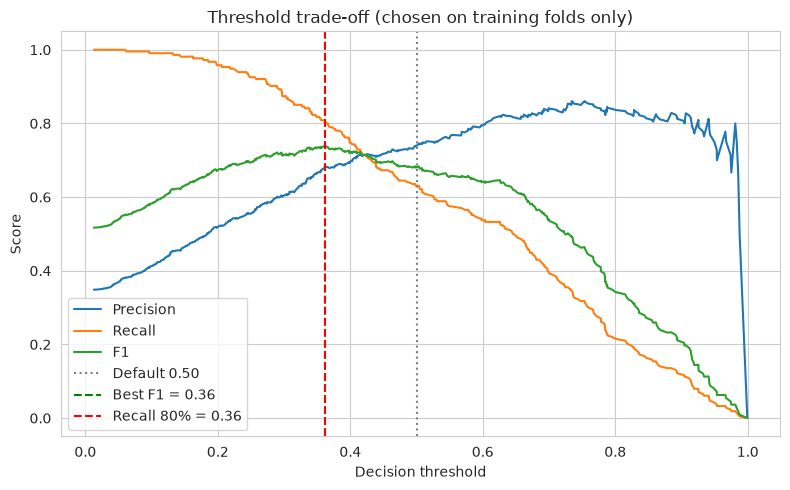

In [22]:
oof_proba = cross_val_predict(best_model, X_train, y_train, cv=CV,
                              method='predict_proba')[:, 1]

prec, rec, thr = precision_recall_curve(y_train, oof_proba)
prec, rec = prec[:-1], rec[:-1]          # align with thr
f1 = 2 * prec * rec / np.maximum(prec + rec, 1e-12)

thr_f1 = float(thr[np.argmax(f1)])

TARGET_RECALL = 0.80
feasible = np.where(rec >= TARGET_RECALL)[0]
thr_recall = float(thr[feasible].max()) if len(feasible) else 0.0

print(f"Threshold maximising F1 (out-of-fold)      : {thr_f1:.3f}")
print(f"Threshold reaching recall >= {TARGET_RECALL:.0%}         : {thr_recall:.3f}")

plt.figure(figsize=(8, 5))
plt.plot(thr, prec, label='Precision')
plt.plot(thr, rec,  label='Recall')
plt.plot(thr, f1,   label='F1')
plt.axvline(0.5, ls=':', c='grey', label='Default 0.50')
plt.axvline(thr_f1, ls='--', c='green', label=f'Best F1 = {thr_f1:.2f}')
plt.axvline(thr_recall, ls='--', c='red', label=f'Recall {TARGET_RECALL:.0%} = {thr_recall:.2f}')
plt.xlabel('Decision threshold')
plt.ylabel('Score')
plt.title('Threshold trade-off (chosen on training folds only)')
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
rows = []
for name, t in [('Default', 0.50), ('Best F1', thr_f1), (f'Recall>={TARGET_RECALL:.0%}', thr_recall)]:
    pred = (y_proba_t >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    rows.append({
        'Rule': name, 'Threshold': round(t, 3),
        'Accuracy': round(accuracy_score(y_test, pred), 3),
        'Balanced acc.': round(balanced_accuracy_score(y_test, pred), 3),
        'Recall (diabetics)': round(recall_score(y_test, pred), 3),
        'Missed diabetics': fn, 'False alarms': fp,
    })

pd.DataFrame(rows)

,Rule,Threshold,Accuracy,Balanced acc.,Recall (diabetics),Missed diabetics,False alarms
0,Default,0.500,0.714,0.682,0.574,23,21
1,Best F1,0.362,0.766,0.782,0.833,9,27
2,Recall>=80%,0.362,0.766,0.782,0.833,9,27


The achieved test recall will not land exactly on the 80% target — the threshold was
picked on the training folds, and the test set is a different sample. That gap *is* the
generalisation gap, made visible.

Read the table as a trade: moving the threshold down converts missed diabetics into false
alarms. Which column matters is a clinical question, not a statistical one — but note that
**ROC-AUC is identical for every row**, because AUC ranks probabilities and never looks at
a threshold. That is why AUC alone cannot tell you whether a screening model is usable.

A related lever is `class_weight='balanced'`, which reweights the likelihood so the
minority class counts more during fitting rather than after it.

In [24]:
weighted = build_pipeline(class_weight='balanced', C=grid.best_params_['clf__C']).fit(X_train, y_train)
wp = weighted.predict_proba(X_test)[:, 1]
wd = (wp >= 0.5).astype(int)

print("class_weight='balanced' at threshold 0.50")
print(f"  Accuracy          : {accuracy_score(y_test, wd):.4f}")
print(f"  Balanced accuracy : {balanced_accuracy_score(y_test, wd):.4f}")
print(f"  Recall (diabetics): {recall_score(y_test, wd):.4f}")
print(f"  ROC-AUC           : {roc_auc_score(y_test, wp):.4f}   <- barely moves")

class_weight='balanced' at threshold 0.50
  Accuracy          : 0.7597
  Balanced accuracy : 0.7724
  Recall (diabetics): 0.8148
  ROC-AUC           : 0.8280   <- barely moves


## 10. Does cleaning the zeros actually help?

**WHY.** The original notebook concluded that fixing the impossible zeros "significantly
impacts model performance" without ever measuring it. Here is the experiment: same
pipeline, same folds, the only difference being whether zeros are treated as real
measurements or as missing.

In [25]:
X_dirty = df.drop(columns='Outcome').loc[X_train.index]   # zeros left as if genuine
X_clean = X_train                                          # zeros already -> NaN -> imputed

s_dirty = cross_val_score(build_pipeline(), X_dirty, y_train, cv=CV, scoring='roc_auc')
s_clean = cross_val_score(build_pipeline(), X_clean, y_train, cv=CV, scoring='roc_auc')

print(f"Zeros kept as real : {s_dirty.mean():.4f} (+/- {s_dirty.std():.4f})")
print(f"Zeros imputed      : {s_clean.mean():.4f} (+/- {s_clean.std():.4f})")
print(f"Difference         : {s_clean.mean() - s_dirty.mean():+.4f}")

diff = s_clean - s_dirty
print(f"\nPaired per-fold differences: {np.round(diff, 4)}")
if np.allclose(diff, 0):
    print("Identical -> your CSV had no zeros to fix (see the §1 audit).")
elif abs(diff.mean()) < s_clean.std():
    print("Smaller than fold-to-fold noise -> a real but modest effect. Say so honestly.")
else:
    print("Larger than fold noise -> cleaning genuinely helped.")

Zeros kept as real : 0.8716 (+/- 0.0167)
Zeros imputed      : 0.8716 (+/- 0.0167)
Difference         : +0.0000

Paired per-fold differences: [0. 0. 0. 0. 0.]
Identical -> your CSV had no zeros to fix (see the §1 audit).


## 11. Conclusions

1. **Audit the file before modelling it.** A `diabetes.csv` whose Insulin values pile up on
   the class medians has the label leaked into the features, and every number downstream is
   fiction. This is the highest-value habit in the whole notebook.
2. **Preprocessing belongs inside the model.** Imputer, scaler and classifier go in one
   `Pipeline` so cross-validation refits them per fold. Preprocessing outside the split is
   the most common source of silently optimistic scores.
3. **Always report a reference.** Accuracy means nothing without the majority-class rate,
   and a point estimate means little without an interval — on ~154 test rows the AUC CI is
   roughly ±0.06 wide, so most model "improvements" are noise.
4. **Two questions, two tools.** scikit-learn for prediction; `statsmodels` for the
   standard errors, z-statistics and p-values in ISLP Table 4.1.
5. **Coefficients are log odds.** exp(beta) is an odds multiplier, per SD on standardised
   features. The effect on probability depends on where you sit on the S-curve, and can
   flip sign between simple and multiple regression when predictors are correlated.
6. **The threshold is yours to choose.** 0.5 is a default, not a result. Pick it on
   training folds against the cost you actually care about; AUC will not do it for you.
7. **Regularisation is chosen by cross-validation** — and the winning CV score is always
   optimistic, because it was used to pick the winner.